# 1번 - 가상 데이터셋을 생성한 뒤, 학습·검증·테스트 데이터셋으로 분할해 보세요

In [ ]:
import numpy as np
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split

* ```
  from sklearn.datasets import make_classification
  ```
  가상 데이터 생성 함수 (직접 데이터 없어도 실습용 데이터를 자동으로 만들어줌)

* ```
  from sklearn.model_selection import train_test_split
  ```
  데이터 분할 함수 (데이터를 원하는 비율로 랜덤하게 나눠줌)



In [ ]:
# 가상 데이터셋 생성
X, y = make_classification( # make_classification: 이진 분류(0 또는 1)용 가상 데이터를 만들어주는 함수
    n_samples=1000,   # 데이터 행 개수 (1000개의 샘플)
    n_features=10,    # 열 개수 (특성 10개)
    random_state=42   # 항상 같은 데이터가 생성되도록 고정 (몇 번을 실행해도 항상 같은 순서로 섞임 → 결과 비교가 공정해짐)
)

print("전체 데이터 크기:", X.shape)

전체 데이터 크기: (1000, 10)


In [ ]:
# 1차 분할: 학습(60%) + 나머지(40%)
X_train, X_temp, y_train, y_temp = train_test_split(  # X랑 y는 항상 같이 쪼개져야함 (데이터-정답 쌍이 유지되어야하기 때문)
    X, y, test_size=0.4, random_state=42  # 전체의 40%를 temp(미완성덩어리)로, 나머지 60%가 자동으로 train
)

In [ ]:
# 2차 분할: 나머지(40%) → 검증(20%) + 테스트(20%)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42  # test_size=0.5인 이유: temp가 이미 40%라서 그걸 반으로 나눠야 각각 20%가 되기 때문
)

In [ ]:
# 결과
print("학습 데이터:", X_train.shape)      # (600, 10)
print("검증 데이터:", X_val.shape)        # (200, 10)
print("테스트 데이터:", X_test.shape)

학습 데이터: (600, 10)
검증 데이터: (200, 10)
테스트 데이터: (200, 10)


# 2번 - 가상 데이터셋을 생성하고, K-최근접이웃(K-NN) 알고리즘으로 학습·예측을 수행해 보세요

## - StandardScale - K-NN에서 스케일링이 중요한 이유

K-NN은 거리로 가까운 이웃을 찾는 알고리즘

```
키:    170cm, 165cm, 180cm  → 차이가 5~15 정도
몸무게: 70kg,  68kg,  72kg  → 차이가 2~4 정도
연봉:  5000만, 3000만, 8000만 → 차이가 수천만
```
거리를 계산하면 연봉의 차이가 압도적으로 커서 키랑 몸무게는 거의 무시되어 버림

그래서 StandardScaler로 **모든 특성을 같은 단위(평균 0, 표준편차 1)로 맞춰주는 것**


```
키:    0.3,  -0.8,  1.2   → 비슷한 범위
몸무게: 0.1,  -0.5,  0.9  → 비슷한 범위  
연봉:  0.2,  -1.1,  1.4   → 비슷한 범위 ← 이제 공평해짐
```

## - fit_transform vs transform
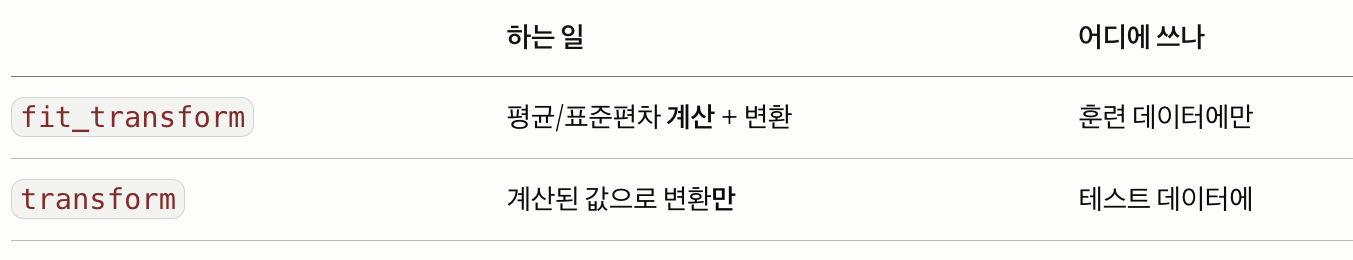

## - reshape(1, -1) - 왜 예측할 때 shape을 바꿀까
상황: 예측할 때 딱 1개 샘플만 넣고 싶음

근데 모델은 **항상 2차원 표 형태로 입력을 받음**

X_test[0]으로 한 행만 꺼내면 1차원이기때문에 모델에 넣으면 에러 발생

```
X_test[0]          # [0.3, -0.5, 1.2, ...]  ← 1차원
X_test[0].shape    # (10,)  ← 열만 있고 행이 없음
```

따라서 **reshape**으로 2차원으로 바꿔주는 것


```
X_test[0].reshape(1, -1)        # [[0.3, -0.5, 1.2, ...]]  ← 2차원
X_test[0].reshape(1, -1).shape  # (1, 10)  ← 행 1개, 열 10개
```
-1의 의미: 열 개수는 알아서 맞춰달라는 뜻



In [ ]:
import numpy as np
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier

In [ ]:
# 가상데이터 생성
X, y = make_classification(
    n_samples=1000,
    n_features=10,
    random_state=42
)
print("전체 데이터 크기:", X.shape)

전체 데이터 크기: (1000, 10)


In [ ]:
# 데이터 분할 (학습 80%, 테스트 20%) - knn은 검증데이터까지는 필요로 하지 않음
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print("학습 데이터 크기:", X_train.shape)
print("테스트 데이터 크기:", X_test.shape)

학습 데이터 크기: (800, 10)
테스트 데이터 크기: (200, 10)


In [ ]:
# 스케일링 (훈련 기준으로 계산, 테스트는 계산 안하고 변환만)
scaler = StandardScaler()   # 스케일러 객체 생성
X_train = scaler.fit_transform(X_train) # 훈련 데이터 기준으로 평균/표준편차 계산 + 변환
X_test = scaler.transform(X_test) # 훈련 기준으로 테스트 데이터 변환만

In [ ]:
# K-NN 모델 생성 & 학습
k = 5 # 이웃 5개를 기준으로 판단
knn_model = KNeighborsClassifier(n_neighbors=k) # K-NN 모델 생성
knn_model.fit(X_train, y_train) # 훈련 데이터 전체를 저장 (K-NN은 별도 학습 없이 저장만 함)

KNeighborsClassifier()

In [ ]:
# 전체 테스트 데이터 정확도
accuracy = knn_model.score(X_test, y_test)  # 테스트 데이터 전체의 정확도 계산
print(f"테스트 정확도: {accuracy:.4f}")

테스트 정확도: 0.7900


In [ ]:
# 샘플 1개 예측
sample = X_test[0].reshape(1, -1)
prediction = knn_model.predict(sample)
print(f"실제 정답: {y_test[0]}")
print(f"예측 결과: {prediction[0]}")

실제 정답: 0
예측 결과: 0


# 3번 - 동일한 이진 분류 가상 데이터셋을 생성하고, Perceptron, SVM, Random Forest, Naive Bayes 네 가지 알고리즘으로 학습해 보세요

### Perceptron

### SVM
> **kernel='linear'**: 선형커널, 직선으로 데이터를 나누겠다는 뜻

❓ 직선으로 못 나누는 데이터는 어떻게 (비선형 데이터)


```
2차원에서 직선으로 못 나누는 데이터
    ↓ 커널 트릭으로 3차원으로 변환
3차원에서는 평면으로 나눌 수 있음
```


### Random Forest
1. **의사결정 트리** (Decision Tree) - **Random Forest 기반**
  
    Random Forest는 의사결정트리 여러개의 묶음임

    * 트리하나의 동작 방법


      ```
      오늘 비가 오나요?
        ├── 예 → 바람이 강한가요?
        │         ├── 예 → 우산 필요
        │         └── 아니오 → 우산 필요
        └── 아니오 → 우산 필요 없음
      ```

2. **앙상블** (Ensemble) - **Random Forest 핵심 원리**


```
나무 1: 0으로 예측
나무 2: 1로 예측       → 다수결 → 최종: 1
나무 3: 1로 예측
```



### Naive Bayes
**베이즈 정리**로 확률 계산 + 독립 가정으로 계산 단순화 = **Naive Bayes**
1. 베이즈 정리란?

    ```
    P(A|B) = P(B|A) × P(A) / P(B)
    ```
    * P(A|B): 증거 B가 주어졌을 때 A일 확률
    * P(B|A): A가 맞을 때 B가 관측될 확률
    * P(A): 사전에 알고 있던 A의 확률
    * P(B): B가 발생할 전체 확률


2. 나이브(Naive) 가정 추가
베이즈 정리에 한 가지 가정을 추가하면 나이브 베이즈가 된다.

    > 모든 특성이 서로 독립적이다

3. 나이브 베이즈 동작 방식


    ```
    1. 입력 데이터가 주어짐
    2. 각 클래스에 속할 확률을 계산
    3. 가장 높은 확률의 클래스로 분류
    ```




In [ ]:
import numpy as np
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Perceptron # 선형 경계선으로 분류
from sklearn.svm import SVC # 마진 최대화 경계선으로 분류
from sklearn.ensemble import RandomForestClassifier # 결정 트리 100개 다수결 투표
from sklearn.naive_bayes import GaussianNB  # 확률 계산으로 분류

In [ ]:
# 가상 데이터 생성 (이진 분류)
X, y = make_classification(
    n_samples=1000,
    n_features=10,
    n_classes=2,       # 이진 분류 (0 또는 1)
    random_state=42
)

In [ ]:
# 데이터 분할 (학습 80%, 테스트 20%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
# 스케일링 (Perceptron, SVM은 거리/경계 기반이라 필수로 해야함)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

* X_train_scaled 으로 변수명을 새로 만든 이유는 **X_train 원본을 보존**하기 위함임


  ```
  X_train_scaled = scaler.fit_transform(X_train)

  print(X_train)        # 원본 그대로 출력 가능
  print(X_train_scaled) # 스케일링된 버전 출력 가능
  ```


  * 원본을 나중에 쓸 일이 있으면 그냥 덮어써도 상관은 없음


    ```
    X_train = scaler.fit_transform(X_train)

    print(X_train) # 이미 스케일링된 값, 원본은 사라짐
    ```




In [ ]:
# 4가지 모델 정의
# 딕셔너리로 묶으면 반복문 한 번으로 4가지를 한꺼번에 처리할 수 있음!
models = {
    "Perceptron"     : Perceptron(random_state=42),
    "SVM"            : SVC(kernel='linear', random_state=42),
    "Random Forest"  : RandomForestClassifier(n_estimators=100, random_state=42),
    "Naive Bayes"    : GaussianNB()
}

In [ ]:
# 학습 & 평가
print("=" * 40)
print(f"{'알고리즘':<20} {'정확도':>10}")
print("=" * 40)

for name, model in models.items():  # models.items(): 딕셔너리에서 (이름, 모델) 쌍을 꺼내기
    # Naive Bayes, Random Forest는 스케일링 불필요
    # 하지만 동일 데이터로 비교하기 위해 스케일링된 데이터 사용
    model.fit(X_train_scaled, y_train)  # model.fit(): 모델 학습
    accuracy = model.score(X_test_scaled, y_test) # model.score(): 정확도 계산
    print(f"{name:<20} {accuracy:>10.4f}") # 왼쪽 정렬, 20칸 확보 / 오른쪽 정렬, 소수점 4자리

print("=" * 40)

알고리즘                        정확도
Perceptron               0.8150
SVM                      0.8300
Random Forest            0.8800
Naive Bayes              0.8100


# 4번 - 가상 데이터셋을 준비하고, 증강(Data Augmentation) 기법을 적용했을 때와 적용하지 않았을 때 모델 성능을 비교하세요

In [ ]:
import numpy as np
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier

In [ ]:
# 가상 데이터 생성
X, y = make_classification(
    n_samples=1000,
    n_features=10,
    random_state=42
)


In [ ]:
# 데이터 분할 (학습 80%, 테스트 20%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
# 스케일링
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
# 증강 (훈련 데이터에만 노이즈 추가)
noise = np.random.normal(0, 0.1, X_train_scaled.shape)  # 평균 0, 표준편차 0.1(수치형: 스케일링된 데이터라 0.1)
X_train_augmented = np.vstack([X_train_scaled, X_train_scaled + noise])
y_train_augmented = np.hstack([y_train, y_train]) #  y를 그대로 두 번 쌓는 이유: 노이즈를 추가했지만 정답 라벨은 바뀌지 않기 때문 (원본이 0이면 노이즈 추가해도 0이고, 원본이 1이면 노이즈 추가해도 1)

### 노이즈 생성


```
noise = np.random.normal(0, 0.1, X_train_scaled.shape)
```



*   0: 노이즈 평균값 (0이면 원본에서 크게 벗어나지 않음)
*   0.1: 노이즈 표준편차 (작을수록 원본과 비슷한 데이터 생성)
*   X_train_scaled.shape: 원본과 똑같은 크기로 노이즈 생성



### vstack  vs  hstack


```
vstack (vertical stack) → 세로로 쌓기
X_train_scaled     (800행 × 10열)
X_train + noise    (800행 × 10열)
─────────────────────────────────
결과               (1600행 × 10열)  ← 행이 늘어남

hstack (horizontal stack) → 가로로 붙이기
y_train     (800개)  +  y_train    (800개)
────────────────────────────────────────
결과        (1600개)               ← 길이가 늘어남
```



In [ ]:
# 증강 없이 학습
model_original = RandomForestClassifier(n_estimators=100, random_state=42)
model_original.fit(X_train_scaled, y_train) # 800개로 학습
accuracy_original = model_original.score(X_test_scaled, y_test) # accuracy_augmented와 같은 테스트 데이터로 평가

In [ ]:
# 증강 적용 후 학습
model_augmented = RandomForestClassifier(n_estimators=100, random_state=42)
model_augmented.fit(X_train_augmented, y_train_augmented) # 1600개로 학습
accuracy_augmented = model_augmented.score(X_test_scaled, y_test) # accuracy_original와 같은 테스트 데이터로 평가

In [ ]:
# 결과 비교
print("=" * 40)
print(f"{'':5} {'데이터 수':>10} {'정확도':>10}")
print("=" * 40)
print(f"{'증강 전':5} {len(X_train_scaled):>10} {accuracy_original:>10.4f}")
print(f"{'증강 후':5} {len(X_train_augmented):>10} {accuracy_augmented:>10.4f}")
print("=" * 40)

           데이터 수        정확도
증강 전         800     0.8800
증강 후        1600     0.8800


전체 흐름
```
원본 데이터 1000개
    ↓ 분할
훈련 800개 / 테스트 200개
    ↓
훈련 데이터에만 노이즈 추가
    ↓
증강 전 800개  →  모델A 학습  →  테스트 200개로 평가
증강 후 1600개 →  모델B 학습  →  테스트 200개로 평가
    ↓
결과 비교
```



# 5번 - 활성화 함수를 직접 정의하고, 활성화 함수를 적용한 출력을 계산하고, 결과를 그래프로 시각화하세요

## 활성화 함수 3가지


```
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def tanh(x):
    return np.tanh(x)

def relu(x):
    return np.maximum(0, x)
```

### 각 함수의 출력 범위

| 함수    | 출력 범위 | 특징               |
|---------|----------|--------------------|
| Sigmoid | 0 ~ 1    | S자 곡선           |
| Tanh    | -1 ~ 1   | S자 곡선, 중심이 0 |
| ReLU    | 0 ~ ∞    | 음수는 0, 양수는 그대로 |

In [ ]:
import numpy as np
import matplotlib.pyplot as plt # 그래프 그리는 라이브러리

In [ ]:
# 활성화 함수 직접 정의
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def tanh(x):
    return np.tanh(x)

def relu(x):
    return np.maximum(0, x)

## 활성화 함수 코드 설명

| 함수    | 코드                    | 의미                        |
|---------|------------------------|-----------------------------|
| Sigmoid | `1 / (1 + np.exp(-x))` | e의 -x승을 계산해서 S곡선 만들기 |
| Tanh    | `np.tanh(x)`           | numpy에 내장된 tanh 함수 사용  |
| ReLU    | `np.maximum(0, x)`     | 0과 x 중 큰 값 반환           |

In [ ]:
# 입력값 범위 설정
x = np.linspace(-5, 5, 100)  # -5 ~ 5 사이 100개의 점



```
np.linspace(시작, 끝, 개수)
→ -5부터 5까지 균일한 간격으로 100개의 점 생성
```



In [ ]:
# 각 함수 출력 계산
y_sigmoid = sigmoid(x)
y_tanh = tanh(x)
y_relu = relu(x)

In [ ]:
# 결과 출력
print("x = -5일 때")
print(f"  Sigmoid : {sigmoid(-5):.4f}")
print(f"  Tanh    : {tanh(-5):.4f}")
print(f"  ReLU    : {relu(-5):.4f}")

print("\nx = 0일 때")
print(f"  Sigmoid : {sigmoid(0):.4f}")
print(f"  Tanh    : {tanh(0):.4f}")
print(f"  ReLU    : {relu(0):.4f}")

print("\nx = 5일 때")
print(f"  Sigmoid : {sigmoid(5):.4f}")
print(f"  Tanh    : {tanh(5):.4f}")
print(f"  ReLU    : {relu(5):.4f}")

x = -5일 때
  Sigmoid : 0.0067
  Tanh    : -0.9999
  ReLU    : 0.0000

x = 0일 때
  Sigmoid : 0.5000
  Tanh    : 0.0000
  ReLU    : 0.0000

x = 5일 때
  Sigmoid : 0.9933
  Tanh    : 0.9999
  ReLU    : 5.0000


### 전체 그래프 크기 설정: (가로, 세로) 인치 단위

**subplot**: 그래프를 격자로 나눠서 그리는 것
**axhline**: 가로선
**axvline** 세로선

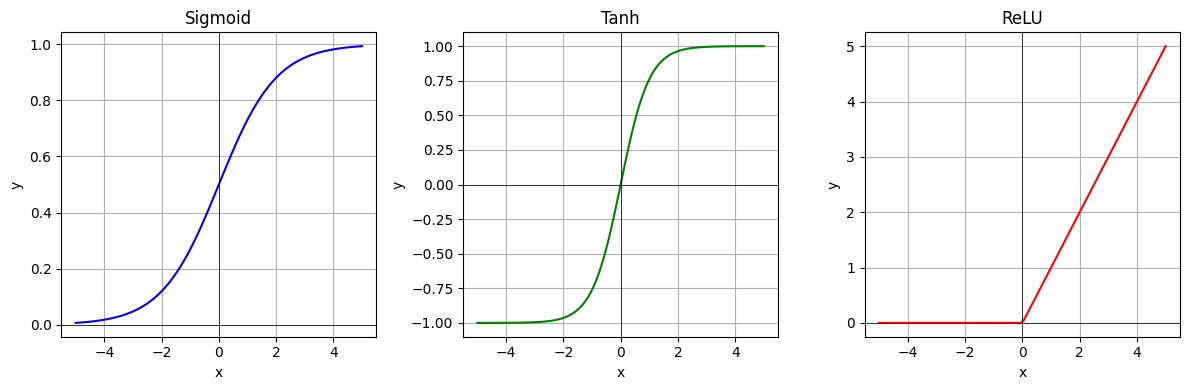

In [ ]:
# 그래프 시각화
plt.figure(figsize=(12, 4))

# Sigmoid
plt.subplot(1, 3, 1)  # # 1행 3열 중 1번째
plt.plot(x, y_sigmoid, color='blue')
plt.title('Sigmoid')
plt.xlabel('x')
plt.ylabel('y')
plt.grid(True)
plt.axhline(0, color='black', linewidth=0.5)  # x축
plt.axvline(0, color='black', linewidth=0.5)  # y축

# Tanh
plt.subplot(1, 3, 2)  # 1행 3열 중 2번째
plt.plot(x, y_tanh, color='green')
plt.title('Tanh')
plt.xlabel('x')
plt.ylabel('y')
plt.grid(True)
plt.axhline(0, color='black', linewidth=0.5)
plt.axvline(0, color='black', linewidth=0.5)

# ReLU
plt.subplot(1, 3, 3)  # 1행 3열 중 3번째
plt.plot(x, y_relu, color='red')
plt.title('ReLU')
plt.xlabel('x')
plt.ylabel('y')
plt.grid(True)
plt.axhline(0, color='black', linewidth=0.5)
plt.axvline(0, color='black', linewidth=0.5)

plt.tight_layout()  # 그래프들이 겹치지 않게 간격 자동 조정
plt.show()  # 화면에 그래프 출력

# 6번 - 비선형 데이터셋을 생성하고, MLP(다층 퍼셉트론) 모델을 설계하고 학습시켜 분류를 수행하세요

## MLP란?
퍼셉트론 하나가 여러 층으로 쌓인 것

```
입력층 (Input Layer)
    ↓
은닉층 (Hidden Layer) × 여러 개  ← 이게 "다층"의 의미
    ↓
출력층 (Output Layer)
```

비선형 데이터 → 곡선으로 나눠야 함 → MLP의 비선형 활성화 함수가 필요


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons # 초승달 모양의 비선형 데이터 생성
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential  # 층을 순서대로 쌓는 모델
from tensorflow.keras.layers import Dense, Input  # Dense: 완전 연결층 (Fully Connected Layer) / Input: 입력 데이터 형태 정의

In [ ]:
# 한글 폰트 설정
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

!apt-get install -y fonts-nanum > /dev/null 2>&1
fm.fontManager.addfont('/usr/share/fonts/truetype/nanum/NanumGothic.ttf')
plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False

In [ ]:
# 비선형 데이터셋 생성
X, y = make_moons(
    n_samples=1000,  # 데이터 1000개 생성
    noise=0.2,       # 노이즈 추가 (비선형성 강화, 0이면 완벽한 초승달, 클수록 흐트러짐)
    random_state=42  # 항상 같은 데이터 생성
)



```
클래스 0: ⌒ 모양
클래스 1: ⌣ 모양
→ 직선 하나로 나눌 수 없음 → 따라서 MLP 필요
```



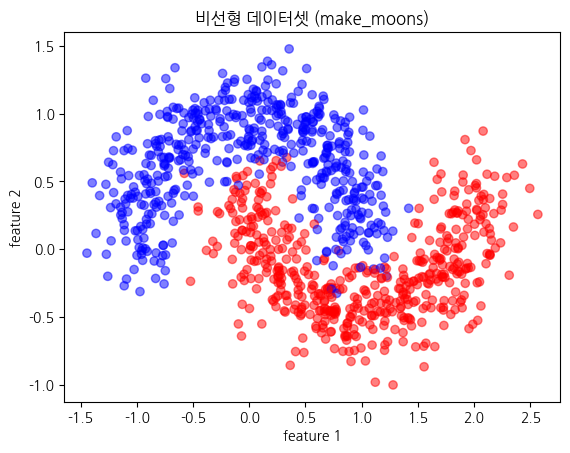

In [ ]:
# 데이터 시각화 (어떻게 생겼는지 확인)
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='bwr', alpha=0.5)
plt.title('비선형 데이터셋 (make_moons)')
plt.xlabel('feature 1')
plt.ylabel('feature 2')
plt.show()

```
X[:, 0]
```

모든 행의 첫 번째 열 (feature 1)

```
X[:, 1]
```

모든 행의 두 번째 열 (feature 2)

```
c=y
```
클래스(0 또는 1)에 따라 색상 구분

```
cmap='bwr'
```
파랑(blue)-흰색(white)-빨강(red) 색상 맵

```
alpha=0.5
```
점 투명도 50%



In [ ]:
# 데이터 분할 (학습 80%, 테스트 20%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
# 스케일링
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
# MLP 모델 설계
model = Sequential([
    Input(shape=(2,)),              # 입력층 (특성 2개: feature1, feature2라서 2)
    Dense(64, activation='relu'),   # 은닉층 1 (64개 뉴런, ReLU로 비선형성 추가)
    Dense(64, activation='relu'),   # 은닉층 2 (64개 뉴런, 더 복잡한 패턴 학습)
    Dense(1, activation='sigmoid')  # 출력층 (이진 분류, 뉴런 1개, sigmoid로 0~1 확률 출력, 0.5 이상이면 클래스 1, 미만이면 클래스 0)
])

In [ ]:
# 모델 컴파일
model.compile(
    optimizer='adam', # 가중치 업데이트 방법 (Adam이 가장 많이 쓰임)
    loss='binary_crossentropy',  # 이진 분류 손실 함수 (binary_crossentropy를 쓰는 이유는 출력이 0 또는 1 두 개뿐인 이진 분류이기 때문)
    metrics=['accuracy']  # 정확도로 성능 평가
)

In [ ]:
# 모델 학습
history = model.fit(
    X_train, y_train,
    epochs=20,  # 전체 데이터를 20번 반복 학습
    batch_size=32,  # 한 번에 32개씩 묶어서 학습
    validation_split=0.2, # 훈련 데이터의 20%를 검증용으로 사용
    verbose=1 # 학습 진행 상황 출력
)

Epoch 1/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.7875 - loss: 0.6016 - val_accuracy: 0.8500 - val_loss: 0.5115
Epoch 2/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8641 - loss: 0.4423 - val_accuracy: 0.8500 - val_loss: 0.3821
Epoch 3/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8672 - loss: 0.3393 - val_accuracy: 0.8500 - val_loss: 0.3139
Epoch 4/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8719 - loss: 0.3012 - val_accuracy: 0.8500 - val_loss: 0.2911
Epoch 5/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8750 - loss: 0.2886 - val_accuracy: 0.8625 - val_loss: 0.2808
Epoch 6/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8781 - loss: 0.2820 - val_accuracy: 0.8625 - val_loss: 0.2759
Epoch 7/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8781 - loss: 0.2762 - val_accuracy: 0.8625 - val_loss: 0.2686
Epoch 8/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8797 - loss: 0.2700 - val_accuracy: 0.8625 - val_loss

In [ ]:
# 모델 평가
loss, accuracy = model.evaluate(X_test, y_test)
print(f"\n테스트 정확도: {accuracy:.4f}")

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9650 - loss: 0.1223  

테스트 정확도: 0.9650


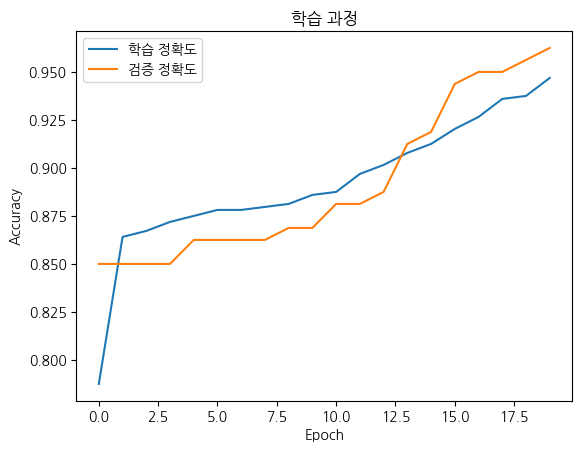

In [ ]:
# 학습 과정 시각화
plt.plot(history.history['accuracy'], label='학습 정확도')  # 매 epoch마다의 학습 정확도 기록
plt.plot(history.history['val_accuracy'], label='검증 정확도')  # 매 epoch마다의 검증 정확도 기록
plt.title('학습 과정')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# 7번 - CNN(Convolutional Neural Network)을 직접 구성하여 이미지 분류를 수행하세요

### CNN의 구조


```
입력 이미지 (32×32×3)
    ↓
Conv2D → ReLU      ← 특징 추출
    ↓
MaxPooling2D       ← 크기 축소
    ↓
Conv2D → ReLU      ← 더 복잡한 특징 추출
    ↓
MaxPooling2D
    ↓
Flatten            ← 3차원 → 1차원으로 펼치기
    ↓
Dense (FC Layer)   ← 분류
    ↓
출력 (클래스 확률)
```



In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense
# Conv2D: 이미지에서 특징 추출하는 합성곱 레이어 / MaxPooling2D: 특징 맵 크기 줄이는 풀링 레이어 / Flatten: 3차원 → 1차원으로 펼치기
from tensorflow.keras.utils import to_categorical
# to_categorical: 정수 라벨 → 원-핫 인코딩 변환

In [ ]:
# 가상 이미지 데이터셋 생성 (32×32 컬러 이미지, 10개 클래스)
num_classes = 10

x_train = np.random.random((1000, 32, 32, 3)).astype(np.float32)
y_train = np.random.randint(num_classes, size=(1000, 1))

x_test = np.random.random((200, 32, 32, 3)).astype(np.float32)
y_test = np.random.randint(num_classes, size=(200, 1))

**1000**: 이미지 1000장

**32, 32**: 이미지 가로×세로 크기

**3**: RGB 채널 (빨강, 초록, 파랑)

**num_classes=10**: 분류할 클래스 10개

In [ ]:
# 원-핫 인코딩
y_train = to_categorical(y_train, num_classes)
y_test = to_categorical(y_test, num_classes)

print("학습 데이터 크기:", x_train.shape)   # (1000, 32, 32, 3)
print("테스트 데이터 크기:", x_test.shape)  # (200, 32, 32, 3)

학습 데이터 크기: (1000, 32, 32, 3)
테스트 데이터 크기: (200, 32, 32, 3)


## 원-핫 인코딩 (One-Hot Encoding)

정수 형태의 클래스 라벨을 이진 벡터로 변환하는 기법

CNN은 10개 클래스를 분류하기 때문에, 각 정수 라벨을 길이 10짜리 벡터로 변환해야 함
해당 클래스 위치만 1이고 나머지는 0으로 채워진다

### 변환 예시

| 정수 라벨 | 원-핫 인코딩 결과               |
|-----------|-------------------------------|
| 0         | [1, 0, 0, 0, 0, 0, 0, 0, 0, 0] |
| 3         | [0, 0, 0, 1, 0, 0, 0, 0, 0, 0] |
| 7         | [0, 0, 0, 0, 0, 0, 0, 1, 0, 0] |

### 왜 필요한가?

MLP (6번 과제) → 클래스가 0 또는 1 두 개 → 원-핫 인코딩 불필요
CNN (7번 과제) → 클래스가 0~9 열 개 → 원-핫 인코딩 필요

모델이 "이 이미지는 3번 클래스일 확률이 높다"처럼
각 클래스별 확률을 출력하려면, 정답도 같은 형태여야 비교가 가능하기 때문이다.

In [ ]:
# CNN 모델 설계
model = Sequential([
    Input(shape=(32, 32, 3)),              # 입력층

    Conv2D(32, (3, 3), activation='relu'), # 합성곱층 1
    MaxPooling2D((2, 2)),                  # 풀링층 1

    Conv2D(64, (3, 3), activation='relu'), # 합성곱층 2
    MaxPooling2D((2, 2)),                  # 풀링층 2

    Conv2D(128, (3, 3), activation='relu'),# 합성곱층 3

    Flatten(),                             # 3차원 → 1차원

    Dense(256, activation='relu'),         # 완전 연결층
    Dense(num_classes, activation='softmax') # 출력층 (10개 클래스)
])



```
Input          (32, 32, 3)   ← 원본 이미지
Conv2D(32)     (30, 30, 32)  ← 32개 특징 추출
MaxPooling2D   (15, 15, 32)  ← 절반으로 축소
Conv2D(64)     (13, 13, 64)  ← 64개 특징 추출
MaxPooling2D   (6, 6, 64)    ← 절반으로 축소
Conv2D(128)    (4, 4, 128)   ← 128개 특징 추출
Flatten        (2048,)        ← 4×4×128 = 2048개로 펼치기
Dense(256)     (256,)         ← 256개 뉴런으로 압축
Dense(10)      (10,)          ← 10개 클래스 확률 출력
```
* 필터 수가 32 → 64 → 128로 늘어나는 이유: 층이 깊어질수록 더 복잡한 패턴을 학습하기 때문


In [ ]:
# 모델 컴파일
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',  # 다중 분류 손실 함수
    metrics=['accuracy']
)

In [ ]:
# 모델 구조 확인
model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 4, 4, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 620,362 (2.37 MB)

 Trainable params: 620,362 (2.37 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# 모델 학습
history = model.fit(
    x_train, y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.1,
    verbose=1
)

Epoch 1/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 65ms/step - accuracy: 0.1056 - loss: 2.3158 - val_accuracy: 0.0900 - val_loss: 2.3104
Epoch 2/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 54ms/step - accuracy: 0.1178 - loss: 2.3063 - val_accuracy: 0.1100 - val_loss: 2.3099
Epoch 3/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 52ms/step - accuracy: 0.1100 - loss: 2.3007 - val_accuracy: 0.0900 - val_loss: 2.3119
Epoch 4/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 68ms/step - accuracy: 0.1144 - loss: 2.3019 - val_accuracy: 0.0900 - val_loss: 2.3109
Epoch 5/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 59ms/step - accuracy: 0.1178 - loss: 2.3010 - val_accuracy: 0.0900 - val_loss: 2.3084
Epoch 6/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 53ms/step - accuracy: 0.0956 - loss: 2.2998 - val_accuracy: 0.0900 - val_loss: 2.3156
Epoch 7/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 54ms/step - accuracy: 0.1178 - loss: 2.2990 - val_accuracy: 0.0900 - val_loss: 2.3157
Epoch 8/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 52ms/step - accuracy: 0.1178 - loss: 2.2976 - val_accuracy: 0.0900 - v

In [ ]:
# 모델 평가
loss, accuracy = model.evaluate(x_test, y_test)
print(f"\n테스트 정확도: {accuracy:.4f}")

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.0600 - loss: 2.3106

테스트 정확도: 0.0600


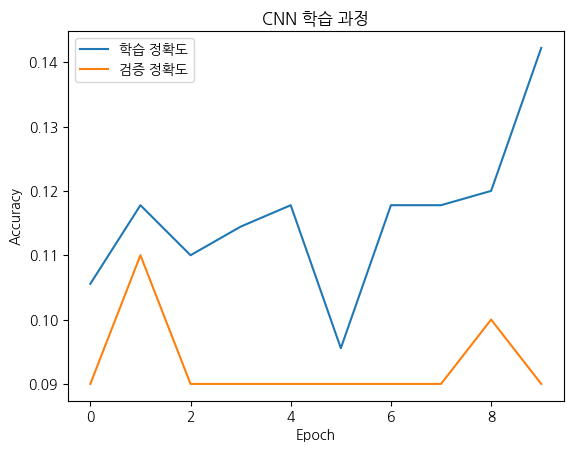

In [ ]:
# 학습 과정 시각화
plt.plot(history.history['accuracy'], label='학습 정확도')
plt.plot(history.history['val_accuracy'], label='검증 정확도')
plt.title('CNN 학습 과정')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()



```
가상 이미지 데이터 생성 (32×32×3)
    ↓
원-핫 인코딩 (정수 → 벡터)
    ↓
CNN 모델 설계
  Conv → Pool → Conv → Pool → Conv
    ↓
Flatten (3차원 → 1차원)
    ↓
Dense → Dense(softmax)
    ↓
학습 & 평가 & 시각화
```

